In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',50)
pd.set_option('display.max_colwidth',80)

plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
df = pd.read_csv('../data/raw/developer-salary-survey.csv', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

Shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [5]:
list(df.columns[165:])

['AIAgentObsWrite',
 'AIAgentExternal',
 'AIAgentExtWrite',
 'AIHuman',
 'AIOpen',
 'ConvertedCompYearly',
 'JobSat']

In [ ]:
# Checking whether we had target column
target_col ='ConvertedCompYearly'
print(f"Target Column Present: {target_col in df.columns}")

Target Column Present: True


In [9]:
# Check how many rows have salary values given
salary_available = df[target_col].notna().sum()

# Check missing rows
salary_missing = df[target_col].isna().sum()

print(f"Rows with Salary: {salary_available}")
print(f"Rows without salary: {salary_missing}")
print(f"Coverage: {salary_available/len(df)*100:.1f}%")

Rows with Salary: 23947
Rows without salary: 25244
Coverage: 48.7%


In [10]:
# Drop rows with missing values
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

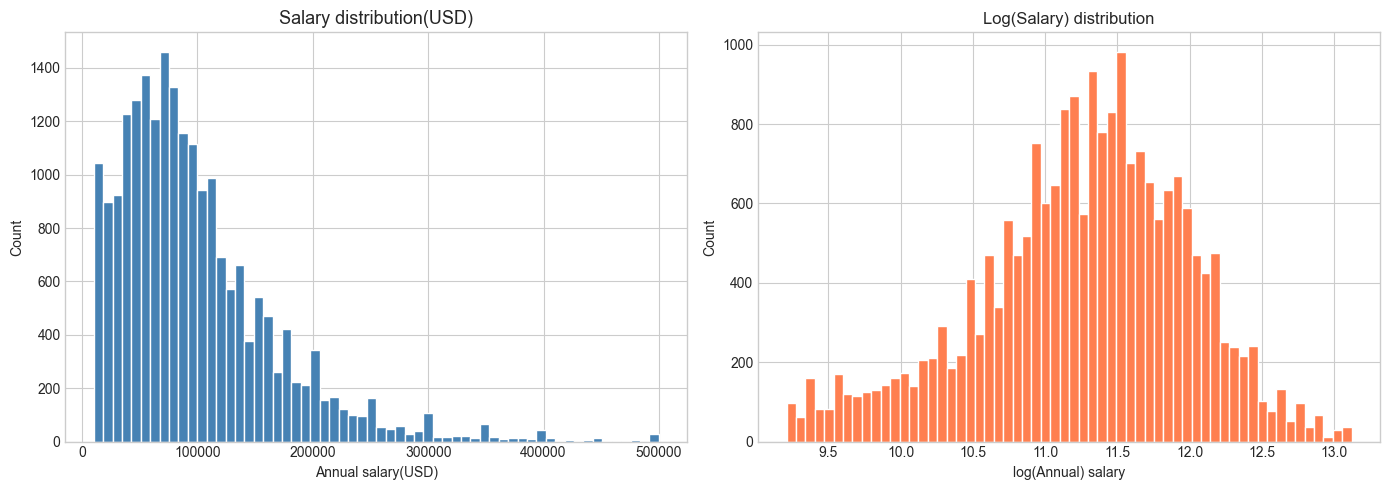

Median salary: $81,870
Mean salary: $98,572


In [15]:
salary_df = df[df[target_col].between(10000, 500000)]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')
 
#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()
 
print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')

Log transformation helps the graph look a bit normmal

# Explore selected features
features =['country','YearsCodepro','Edlevel','employment','Language', Have worked with']

missing columns/rows and how to deal with them
data types hwo do the olumns look like
map heatmap to check for correlation and what are you going to about it